## D2D Example: CLD on Alzheimer's Disease
In this example, we  implement a diagrams-to-dynamics (D2D) analysis of a causal loop diagram (CLD) published by Uleman et al (2020) doi: 10.1007/s11357-020-00228-7. This CLD was turned into a data-driven system dynamics model (SDM) in Uleman (2023) doi: 10.1002/alz.12923. 

In Kumu, the SDM looks as follows:

<img src="Alzheimer CLD.jpg" alt="drawing" width="500"/>

To analyze this CLD, we will first imports the settings and the Kumu file. We will then run the simulations with what-if scenarios, assess the intervention effects, and then perform sensitivity analysis over the model parameters.

In [1]:
import os
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
from systemdynamics.plots import plot_simulated_intervention_ranking

current_path = os.getcwd()  # Select current path
file_name = "Alzheimer"  # Specify the relevant name of the CLD Excel file
file_path = os.path.join(current_path, f"{file_name}.xlsx")

extract = Extract(file_path)  # Load the relevant Kumu file extraction module
s = extract.extract_settings()  # Extract the settings using the Kumu Excel file

# Set simulation settings
s.seed = 1912884
s.N = 200  # Number of simulations
s.t_end = 20  # Timeframe of the simulation
s.time_unit = "quarter-years"  # Base unit of time (time unit of t_end and dt)
s.parameter_value_aux = 0.3
s.parameter_value_stocks = 0.1

# Load the module for formulating and simulating the SDM
sdm = SDM(s)  


Variable of interest: Cognitive functioning
with 15 intervention variables
Removed 2.0 incoming links for constant Diabetes
Removed 4.0 incoming links for constant Dyslipidaemia
Removed 6.0 incoming links for constant Social relationships
Removed 1.0 incoming links for constant Hearing loss
Removed 2.0 incoming links for constant Smoking
Removed 1.0 incoming links for constant Excessive alcohol use
Removed 4.0 incoming links for constant Motor function

75 feedback loops of maximum length 5
All loops have at least one stock


Given these settings, we can now run simulations from the SDM-converted CLD.

In [2]:
df_sol, param_samples, eig_val_vec = sdm.run_simulations()  # Run the simulated interventions
intervention_effects_per_voi = sdm.get_intervention_effects()  # Get the intervention effects

Running Simulations:  12%|█▏        | 23/200 [04:20<33:28, 11.35s/it]

Running Simulations: 100%|██████████| 200/200 [8:56:07<00:00, 160.84s/it]   


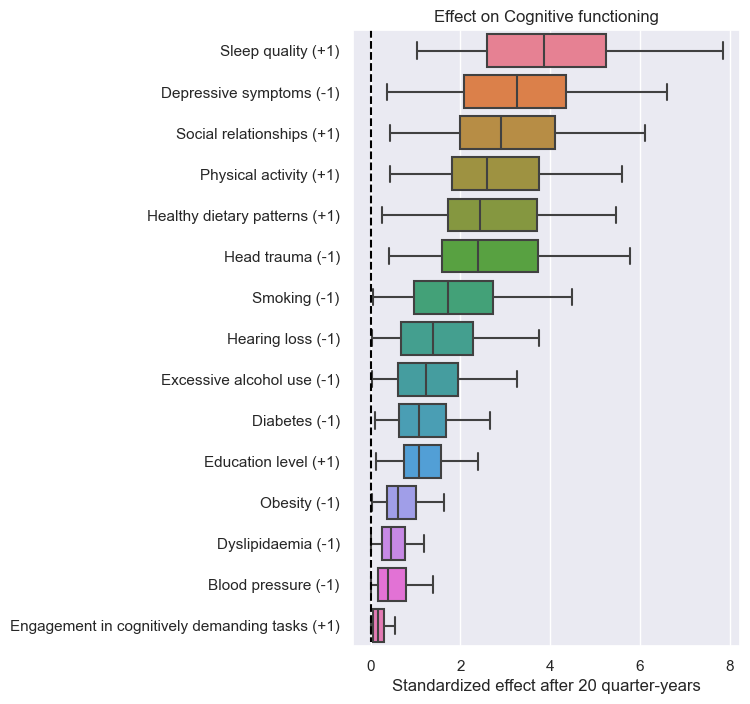

In [3]:
for voi in s.variable_of_interest:
    plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi], 
                                        voi, top_plot=None, order=None);  # Plot the simulated interventions ranking

In [6]:
for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    sdm.compare_interventions_table(intervention_effects_per_voi[voi])  # Print the table of the simulated interventions
    print("")

---- Variable of Interest:  Cognitive_functioning

Comparison Table (Percentage Greater, 95% CI, Cliff’s Delta):
+--------------------------+-------------------------------------------+-------------+----------------------+-----------------+
| Intervention A           | Intervention B                            |   % Greater | 95% CI (% Greater)   |   Cliff's Delta |
+==========================+===========================================+=============+======================+=================+
| Sleep_quality            | Depressive_symptoms                       |        73   | [67.0, 79.5]         |            0.46 |
+--------------------------+-------------------------------------------+-------------+----------------------+-----------------+
| Sleep_quality            | Social_relationships                      |        78   | [72.0, 84.0]         |            0.56 |
+--------------------------+-------------------------------------------+-------------+----------------------+----------

## Sensitivity analysis

In [7]:
## Estimate spearman correlation for the model parameters, either for one intervention variable (int_var) or for all
cut_off_SA_importance = 0.05
int_var = None # If None, the simulations of all intervention will be used

for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    outcome_var = voi  # If None, all variables will be used to assess change in the model
    SA_results, df_SA = sdm.run_SA(outcome_var, int_var, cut_off_SA_importance)
    print("")


---- Variable of Interest:  Cognitive_functioning
+------------------------------------------------------------------+----------------------+---------+--------------------+
|                             Variable                             | Spearman correlation | p-value | 95% CI (bootstrap) |
+------------------------------------------------------------------+----------------------+---------+--------------------+
|           Neuronal_dysfunction->Cognitive_functioning            |        -0.24         |   0.0   |   [-0.27, -0.2]    |
|            Depressive_symptoms->Cognitive_functioning            |        -0.13         |   0.0   |   [-0.17, -0.09]   |
|               Hearing_loss->Cognitive_functioning                |        -0.11         |   0.0   |   [-0.14, -0.07]   |
|           Neuronal_connectivity->Cognitive_functioning           |         0.1          |   0.0   |    [0.07, 0.14]    |
|               Brain_atrophy->Cognitive_functioning               |        -0.09        

## Additional figures

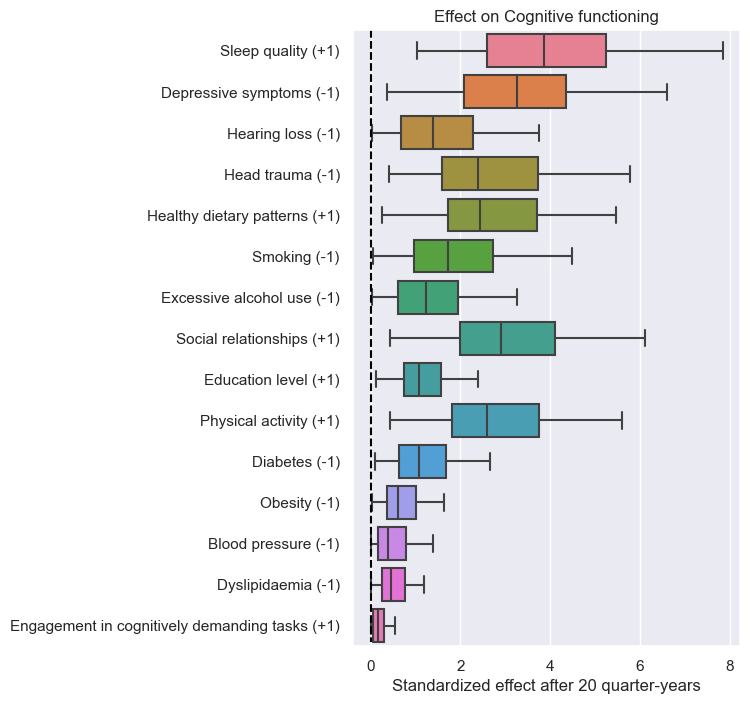

In [8]:
datadriven_ranking = ["Sleep_quality", "Depressive_symptoms", "Hearing_loss", "Head_trauma", 
                      "Healthy_dietary_patterns", "Smoking", "Excessive_alcohol_use", 
                      "Social_relationships", "Education_level", "Physical_activity", 
                      "Diabetes", "Obesity", "Blood_pressure", "Dyslipidaemia", 
                      "Engagement_in_cognitively_demanding_tasks"]

plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi], voi,
                                    top_plot=None, order=datadriven_ranking);

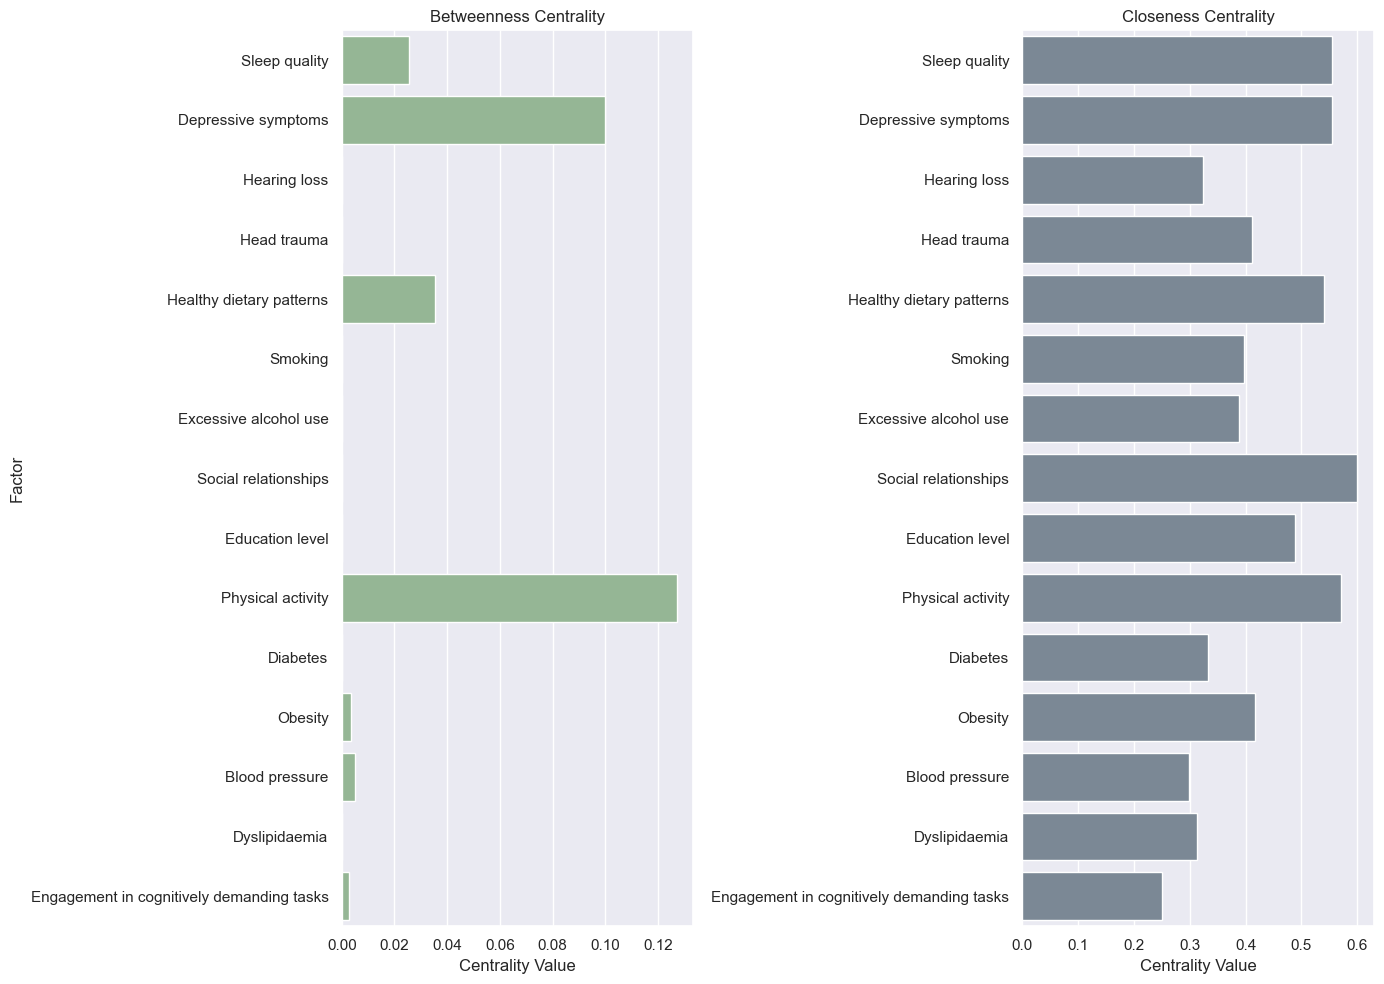

In [9]:
## Centrality plot for comparison
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

def plot_centrality(s, datadriven_ranking):
    """ Plot the betweenness and closeness centrality rankings of the system for comparison purposes.
    """
    datadriven_ranking = [" ".join(x.split('_')) for x in datadriven_ranking]

    # Create a DataFrame
    centrality_df = pd.DataFrame(s.centrality)
    centrality_df["Factor"] = centrality_df.index

    # Filter for the selected 15 factors
    centrality_df = centrality_df[centrality_df["Factor"].isin([var.replace('_', ' ') for var in s.intervention_variables])]

    # Sort DataFrames by centrality values
    df_betweenness = centrality_df.sort_values(by="betweenness", ascending=False)
    df_closeness = centrality_df.sort_values(by="closeness", ascending=False)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharex=False)
    #fig, axes = plt.subplots(1, 1, figsize=(7, 10), sharex=True)
    sns.barplot(data=df_betweenness.loc[datadriven_ranking, :], y="Factor", x="betweenness", ax=axes[0], color='darkseagreen')
    axes[0].set_title("Betweenness Centrality")
    axes[0].set_xlabel("Centrality Value")
    axes[0].set_ylabel("Factor")

    sns.barplot(data=df_closeness.loc[datadriven_ranking, :], y="Factor", x="closeness", ax=axes[1], color='lightslategray')
    axes[1].set_title("Closeness Centrality")
    axes[1].set_xlabel("Centrality Value")
    axes[1].set_ylabel("")  # Remove y-axis label to avoid redundancy

    plt.tight_layout()
    plt.show()

plot_centrality(s, datadriven_ranking)